# `mosaic(bounds=...)` - Sentinel-2 mosaics for arbitrary bounding boxes

Instead of passing an MGRS tile via `grid_id`, you can pass a `bounds` tuple to mosaic any rectangular area, including areas that intersect Sentinel-2 tile boundaries.

In [1]:
from pathlib import Path
import json

import numpy as np
from matplotlib import pyplot as plt

from s2mosaic import mosaic


def plot_rgb(array, title=None, figsize=(8, 6)):
    """Display B04/B03/B02-style arrays with a robust percentile stretch."""
    rgb = np.moveaxis(array[:3], 0, -1).astype(float)
    valid = rgb[np.isfinite(rgb) & (rgb > 0)]
    if valid.size == 0:
        raise ValueError("No positive finite pixels to display")
    lo, hi = np.nanpercentile(valid, [2, 98])
    if not np.isfinite(hi - lo) or hi <= lo:
        hi = np.nanmax(valid)
        lo = np.nanmin(valid)
    rgb_disp = np.clip((rgb - lo) / max(hi - lo, 1), 0, 1)

    plt.figure(figsize=figsize)
    plt.imshow(rgb_disp)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

## 1. Basic usage - small bounds in EPSG:4326

Bounds are `(minx, miny, maxx, maxy)`. The default `input_crs=4326`, so this is a lon/lat box. Output CRS is auto-picked from the bbox centroid.

In [2]:
# ~5km AOI near Perth, WA
bounds = (115.83, -31.97, 115.91, -31.94)

array, profile = mosaic(
    bounds=bounds,
    start_year=2023,
    start_month=6,
    start_day=1,
    duration_months=2,
    bands=["B04", "B03", "B02"],
    mosaic_method="percentile",
    percentile=50,
)

print(f"Shape: {array.shape}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

Shape: (3, 340, 760)
CRS:   EPSG:32750
Pixel: 10.0m


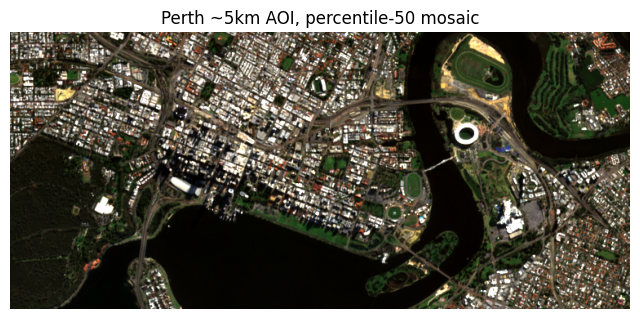

In [3]:
plot_rgb(array, "Perth ~5km AOI, percentile-50 mosaic")

## 2. Lower resolution and bilinear resampling

`resolution` is in metres of the output pixel. At 30 m, rasterio can read from COG overviews rather than the native 10 m file, which usually means much less data over the wire.

In [4]:
array, profile = mosaic(
    bounds=bounds,
    start_year=2023,
    start_month=6,
    duration_days=14,
    bands=["B04", "B03", "B02"],
    mosaic_method="mean",
    resolution=30,
    resampling_method="bilinear",
    additional_query={"eo:cloud_cover": {"lt": 50}},
)

print(f"Shape: {array.shape}")
print(f"Pixel size: {profile['transform'].a}m")

Shape: (3, 113, 253)
Pixel size: 30.0m


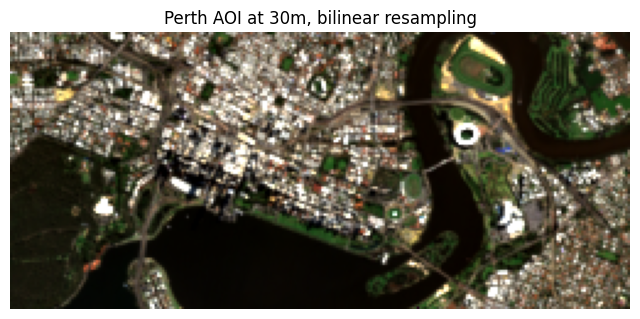

In [5]:
plot_rgb(array, "Perth AOI at 30m, bilinear resampling", figsize=(8, 8))

## 3. Four-tile AOI with mixed UTM projections

Sentinel-2 tile footprints overlap, so even a small AOI can be covered by scenes from several MGRS tiles. Bounds mode reprojects those scenes onto one output grid.

In [6]:
cross_bounds = (144.422, -37.953, 144.462, -37.913)

array, profile = mosaic(
    bounds=cross_bounds,
    start_year=2023,
    start_month=1,
    duration_months=1,
    bands=["B04", "B03", "B02"],
    mosaic_method="percentile",
    percentile=50,
)

print(f"Shape: {array.shape}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

Shape: (3, 454, 364)
CRS:   EPSG:32755
Pixel: 10.0m


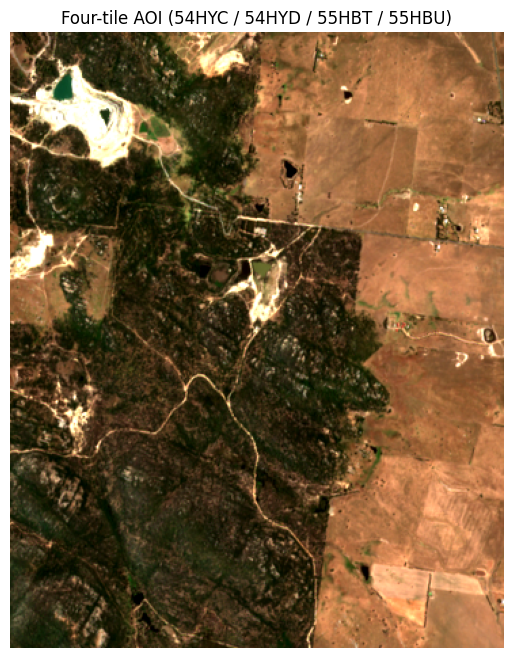

In [7]:
plot_rgb(array, "Four-tile AOI (54HYC / 54HYD / 55HBT / 55HBU)", figsize=(8, 8))

## 4. Save to disk and inspect metadata

Pass `output_dir` and the GeoTIFF is written with an auto-generated filename. A matching `.json` sidecar records the normalized request metadata. Small bounds exports are usually MB-scale, unlike full-tile grid exports.

In [8]:
result = mosaic(
    bounds=bounds,
    start_year=2023,
    start_month=6,
    duration_days=14,
    output_dir=Path("output"),
    bands=["B04", "B03", "B02"],
    mosaic_method="percentile",
    percentile=50,
    additional_query={"eo:cloud_cover": {"lt": 50}},
)
print(f"Saved to: {result}")

metadata_path = result.with_suffix(".json")
metadata = json.loads(metadata_path.read_text())
print(f"Metadata: {metadata_path}")
summary = {
    "mode": metadata["mode"],
    "start_date": metadata["start_date"],
    "end_date": metadata["end_date"],
}
summary.update(
    {
        key: metadata["request"][key]
        for key in ["bands", "mosaic_method", "resolution", "source"]
    }
)
print(summary)

Saved to: output/bbox-115p8300_neg31p9700_115p9100_neg31p9400_2023-06-01_to_2023-06-15_B04-B03-B02_percentile-p50_scene-valid_data_10m_OCM_MPC_4cf3e760be.tif
Metadata: output/bbox-115p8300_neg31p9700_115p9100_neg31p9400_2023-06-01_to_2023-06-15_B04-B03-B02_percentile-p50_scene-valid_data_10m_OCM_MPC_4cf3e760be.json
{'mode': 'bounds', 'start_date': '2023-06-01', 'end_date': '2023-06-15', 'bands': ['B04', 'B03', 'B02'], 'mosaic_method': 'percentile', 'resolution': 10, 'source': 'MPC'}
